# Confronto fra Quicksort e Counting Sort

---

## Introduzione

Lo scopo di questa relazione è quello di confrontare l'efficienza di due algoritmi di ordinamento: il *Quicksort* e il *Counting Sort* evidenziandone le complessità e la convenienza d'utilizzo in base alle situazioni. 


## Quicksort

### Descrizione
Il Quicksort è un algoritmo di ordinamento basato sul paradigma *dividi et impera*. L'idea fondamentale consiste nel selezionare ad ogni passo iterativo, un elemento detto *pivot*, attorno al quale si effettua una riorganizzazione degli elementi. 

Si effettua un'operazione detta di *partizionamento*, che sposta *sul posto*, ovvero senza l'utilizzo di vettori esterni, tutti gli elementi minori del pivot alla sua sinistra e tutti gli elementi maggiori del pivot alla sua destra. Una volta completata questa operazione, l'algoritmo viene applicato alle due sottosequenze ottenute finché ciascuna di queste non risulta composta da un singolo elemento.

Un punto cardine di questo algoritmo è la scelta del pivot. In molte implementazioni viene solitamente scelto l'ultimo elemento del vettore considerato ad una data iterazione, tuttavia questo espone il Quicksort ad un **caso pessimo**, infatti se l'algoritmo è già ordinato, in senso crescente o decrescente, ogni partizionamento generarà una sezione vuota e una di lunghezza $n-1$ portando la complessità a $O(n^2)$.
Si è soliti ovviare a questa possibilità andando a prendere un pivot casuale che dà vita ad una variante del Quicksort chiamata *Randomized Quicksort* che ha complessità $O(n logn)$ a prescindera dall'input.

In questo esperimento verrà utilizzata la versione classica del Quicksort, con il primo elemento come scelta del pivot, per evidenziare proprio questo caso pessimo.
### Complessità

|Caso|Complessità|Descrizione|
|---|---|---|
|Migliore|$O(n \log n)$| Il pivot divide il vettore in due parti uguali ad ogni iterazione|
|Medio|$O(n \log n)$| Caso atteso con bilanciamento fra suddivisioni buone e cattive|
|Peggiore|$O(n^2)$|Il vettore è già ordinato|

### Algoritmo

In [1]:
def partition(seq, start, stop):
    pivotIndex = start
    pivot = seq[pivotIndex]
    i = start + 1
    j = stop - 1

    while i <= j:
        while i <= j and seq[i] <= pivot:
            i += 1
        while i <= j and pivot < seq[j]:
            j -= 1

        if i < j:
            tmp = seq[i]
            seq[i] = seq[j]
            seq[j] = tmp
            i += 1
            j -= 1

    seq[pivotIndex] = seq[j]
    seq[j] = pivot

    return j

In [2]:
def quicksort(seq, start, stop):
    if start >= stop - 1:
        return

    pivotIndex = partition(seq, start, stop)

    quicksort(seq, start, pivotIndex)
    quicksort(seq, pivotIndex + 1, stop)

### Esempio di Utilizzo

In [3]:
seq = [23, 61, 93, 84, 16, 56, 46, 2, 55, 95]
quicksort(seq, 0, len(seq))
print('La lista ordinata è:', seq)

La lista ordinata è: [2, 16, 23, 46, 55, 56, 61, 84, 93, 95]


## Counting Sort

### Descrizione

Il Counting Sort è un algoritmo di ordinamento *non comparativo*, ovvero che non ricorre a confronti diretti fra i valori per capirne l'ordine, e *stabile*, ovvero che preserva l'ordine relativo originale fra elementi aventi lo stesso valore. 

Il funzionamento del Counting Sort si articola in tre fasi principali:

- Nella prima fase si individua il valore massimo $k$ presente nel vettore di input e si alloca un vettore ausiliario $C$ di dimensione $k+1$ inizializzato a zero, e si scorre il vettore di input incrementando $C[v]$ per ogni valore $v$ incontrato. Al termine di questa fase, $C[i]$ contiene il numero di occorrenze del valore $i$ nel vettore originale.
- Nella seconda fase si applica una somma degli indici al nuovo vettore creato. Al termine di questa operazione, $C[i]$ non rappresenta più il numero di occorrenze di $i$, bensì la posizione finale dell'ultima occorrenza di $i$ nel vettore ordinato.
- Nella terza fase si costruisce il vettore di output scorrendo il vettore di input da destra verso sinistra collocando ciascun elemento $v$ nella posizione corretta $C[v]$ del vettore di output. 

Per via della sua stabilità, l'algoritmo Counting Sort viene spesso utilizzato come base del **Radix Sort**, che lo applica iterativamente su ciascuna cifra dei valori da ordinare.
Il Counting Sort funziona solamente con numeri interi positivi.

### Complessità

La Complessità del Counting Sort non varia al variare della *permutazione* dell'input, bensì in base al range dei valori. Risulta conveniente solamente quando $k = O(n)$, ovvero quando il range dei valori è proporzionale alla dimensione del vettore da ordinare. In questi casi la complessità si riduce a $O(n)$.


|Caso|Complessità|Descrizione|
|---|---|---|
|Migliore|$O(n + k)$| Caso generale|
|Medio|$O(n + k)$| La complessità non varia|
|Peggiore|$O(n + k)$|La complessità non varia|

### Algoritmo


In [4]:
def counting_sort(seq):
    size = len(seq)
    maxval = max(seq)
    countSeq = [0] * (maxval + 1)

    # Conto la ricorrenza di ogni elemento
    for v in seq:
        countSeq[v] += 1

    # Sommo gli indici degli elementi
    for i in range(1, maxval + 1):
        countSeq[i] += countSeq[i - 1]

    # Costruisco il risultato
    ans = [0] * size
    
    for i in range(size - 1, -1, -1):
        v = seq[i]
        ans[countSeq[v] - 1] = v
        countSeq[v] -= 1

    return ans

### Esempio di Utilizzo

In [5]:
seq = [43, 35, 16, 87, 74, 45, 100, 64, 50, 30]
ordered_list = counting_sort(seq)
print('La lista ordinata è:', ordered_list)

La lista ordinata è: [16, 30, 35, 43, 45, 50, 64, 74, 87, 100]


---

## Esperimento

Lo scopo degli esperimenti è misurare e confrontare i tempi di esecuzione del Quicksort e del Counting Sort al variare della dimensione dell'input e delle permutazioni dei dati forniti.

Per ciascun esperimento, la dimensione massima dell'array è fissata a $n = (\text{size} \cdot \text{step})$ elementi. Le misurazioni vengono effettuate su $\text{step}$ campioni di dimensione crescente, spaziati di $\text{size}$ elementi l'uno dall'altro. Per attenuare le fluttuazioni dovute alla casualità dell'input e al rumore di sistema, ogni misurazione viene ripetuta $\text{repeat} = 3$ volte e il tempo registrato corrisponde alla media aritmetica delle tre esecuzioni.

Vengono condotti tre esperimenti, ciascuno su un tipo di lista differente:
1. **Lista casuale con range ampio:** il vettore è composto da valori estratti casualmente nell'intervallo $[1, 1\,000\,000]$. In questo caso il parametro $k$ del Counting Sort è molto grande rispetto a $n$, condizione che lo sfavoreggerà.
2. **Lista casuale con range ristretto:** il vettore è composto da valori estratti casualmente nell'intervallo $[1, 100]$, con alta probabilità di valori ripetuti. In questo caso $k \ll n$ ovvero la condizione favorevole per il Counting Sort.
3. **Lista ordinata:** il vettore contiene i valori da $0$ a $n-1$ in ordine crescente. Questo scenario rappresenta il **caso peggiore** per la versione classica del Quicksort, la cui complessità degenera a $O(n^2)$, mentre non influisce sulla complessità del Counting Sort.


Esperimento numero 1:


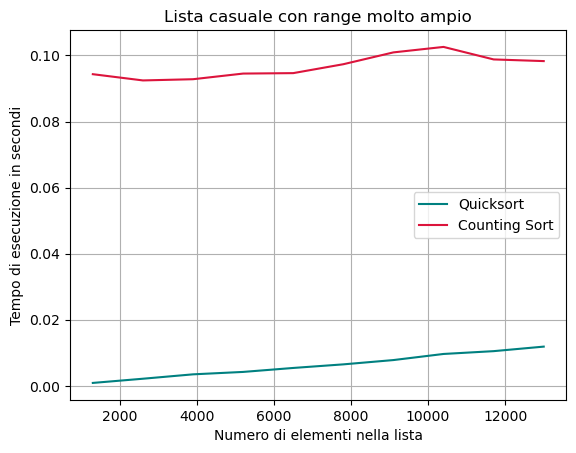

Esperimento numero 2:


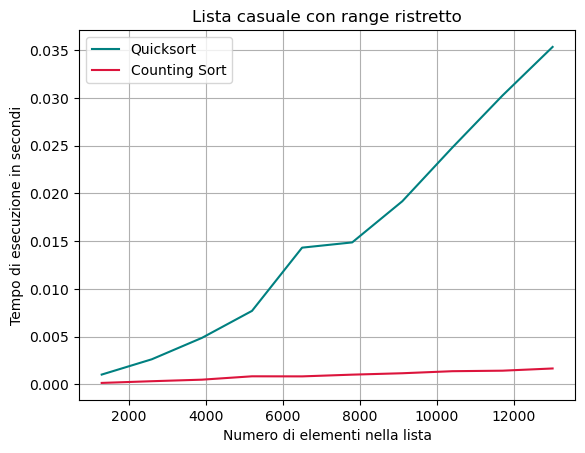

Esperimento numero 3:


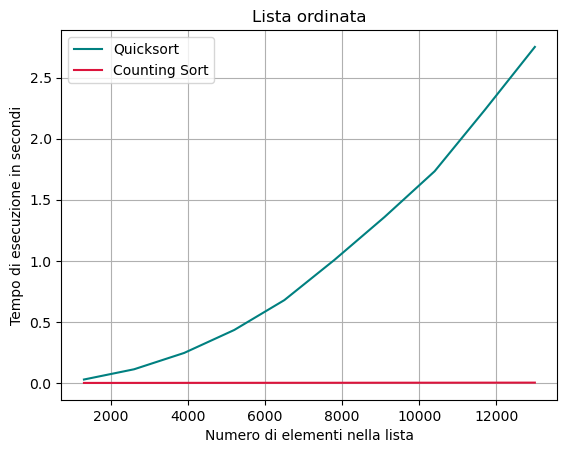

In [6]:
import random
from timeit import default_timer as timer
import matplotlib.pyplot as plt
import sys
sys.setrecursionlimit(10 ** 9)

# Creo la lista completamente randomizzata su un range molto ampio
def big_range_list(size):
    return random.choices(range(1, 1_000_001), k=size)
    
# Creo una lista di grande dimensione ma con range ristretto e valori ripetuti
def small_range_list(size):
    return random.choices(range(1, 101), k=size)

# Creo la lista ordinata in modo crescente
def ordered_list(size):
    return list(range(size))

def experiment(seq_type_func, size, step, name):
    time_quicksort = []
    time_counting_sort = []
    size_sampling = []
    times = []
    repeats = 3

    seq_max = seq_type_func(size * step)

    for i in range(step):
        x = size * (i + 1)
        size_sampling.append(x)
        seq = seq_max[:x]
        
        # print('Campionando il tempo con lista di dimensione', x, '')

        # Eseguo i test 3 volte per ogni dimensione e prendo la media
        
        # Comincio il test per il quicksort
        times.clear()
        for j in range(repeats):
            tmp = seq.copy()
            start = timer()
            quicksort(tmp, 0, len(tmp))
            end = timer()
            times.append(end - start)
        time_quicksort.append(sum(times) / repeats)
       
        # Comincio il test per il counting sort
        times.clear()
        for j in range(repeats):
            start = timer()
            counting_sort(seq) #Non occorre fare una copia della lista per il counting sort
            end = timer()
            times.append(end - start)
        time_counting_sort.append(sum(times) / repeats)
    
    plt.plot(size_sampling, time_quicksort, label = 'Quicksort', color = 'teal')
    plt.plot(size_sampling, time_counting_sort, label = 'Counting Sort', color = 'crimson')
    plt.xlabel('Numero di elementi nella lista')
    plt.ylabel('Tempo di esecuzione in secondi')
    plt.title(label = name)
    plt.grid(True)
    plt.legend()
    plt.show()

def main():
    size = 1300
    step = 10

    print('Esperimento numero 1:')
    experiment(big_range_list, size, step, 'Lista casuale con range molto ampio')
    
    print('Esperimento numero 2:')
    experiment(small_range_list, size, step, 'Lista casuale con range ristretto')
    
    print('Esperimento numero 3:')
    experiment(ordered_list, size, step, 'Lista ordinata')

    
main()

---

## Conclusioni

Osservando i grafici si possono confermare tutte quante le ipotesi iniziali.

Il Counting Sort dimostra prestazioni superiori nei casi in cui il range dei valori $k$ è dell'ordine di $n$, raggiungendo la complessità lineare $O(n + k)$ prevista dalla teoria. Tuttavia, al crescere di $k$, il vantaggio si riduce progressivamente fino ad annullarsi, rendendo l'algoritmo inadeguato in presenza di range arbitrariamente ampi.

Il Quicksort, nella sua versione classica, ha evidenziato il comportamento atteso $O(n^2)$ sui casi pessimi. Nonostante ciò, su input casuali con range ampio ha mantenuto prestazioni ottime, confermando la complessità media $O(n \log n)$.

Possiamo concludere che il Counting Sort rappresenta la scelta preferibile qualora le proprietà dell'input siano note a priori e il range dei valori sia sufficientemente ristretto rispetto alla dimensione del vettore. Il Quicksort, al contrario, si presenta come la soluzione più adeguata nei contesti a elevata variabilità dell'input o in assenza di informazioni preliminari sulla distribuzione dei dati. A ciò si aggiunge il fatto che, operando *sul posto*, il Quicksort non richiede memoria ausiliaria, rendendolo preferibile nei contesti in cui questa è limitata.

## Bibliografia e Sitografia

- [Generate a random list in python - GeeksforGeeks](https://www.geeksforgeeks.org/python/generating-random-number-list-in-python/)
- [Counting sort - Wikipedia](https://en.wikipedia.org/wiki/Counting_sort)
- [Counting sort - GeeksforGeeks](https://www.geeksforgeeks.org/dsa/counting-sort/)
- [Change plot color - Matplotlib Documentation](https://matplotlib.org/stable/users/explain/colors/colors.html)